Case Study: SONAR — Detecting Mines vs. Rocks

1️⃣ Business Objective

Goal:
To build an intelligent system that can automatically detect whether an underwater sonar signal is reflected from a metallic mine (potentially dangerous) or a harmless rock.

This is vital for:
* Maritime safety: Prevent ships and submarines from colliding with mines.
* Naval defense: Identify and safely remove underwater mines.
* Resource exploration: Distinguish between useful metal structures and natural seabed objects.

2️⃣ Problem Statement

In underwater environments, sonar (sound navigation and ranging) is used to detect objects. However, raw sonar signals can be noisy and difficult for humans to interpret consistently.

This dataset:
* Contains 208 sonar returns.
  * 111 are from metal cylinders (mines).
  * 97 are from rocks.
* Each sonar return is represented by 60 numeric features, each measuring the energy of the signal in a frequency band.

The problem:
👉 To train a Deep learning model that can learn the difference in signal patterns and classify new sonar signals as either Mine (M) or Rock (R) — accurately and reliably.


Dataset: "sonardataset.csv"


Features (Inputs)

* There are 60 numerical variables, each representing the energy in a specific frequency band of the sonar signal.
* In the original dataset, they’re just unnamed columns V1, V2, ..., V60 — you can keep it clear and simple:

Target (Output)

* The label is a single categorical variable indicating:
  * "M" for Mine
  * "R" for Rock
____________________________________________________________________

**Tasks**

1. Data Exploration and Preprocessing

* Begin by loading and exploring the "Alphabets_data.csv" dataset. Summarize its key features such as the number of samples, features, and classes.
* Execute necessary data preprocessing steps including data normalization, managing missing values.

2. Model Implementation

* Construct a basic ANN model using your chosen high-level neural network library. Ensure your model includes at least one hidden layer.
* Divide the dataset into training and test sets.
* Train your model on the training set and then use it to make predictions on the test set.

3. Hyperparameter Tuning

* Modify various hyperparameters, such as the number of hidden layers, neurons per hidden layer, activation functions, and learning rate, to observe their impact on model performance.
* Adopt a structured approach like grid search or random search for hyperparameter tuning, documenting your methodology thoroughly.

4. Evaluation

* Employ suitable metrics such as accuracy, precision, recall, and F1-score to evaluate your model's performance.
* Discuss the performance differences between the model with default hyperparameters and the tuned model, emphasizing the effects of hyperparameter tuning.

Evaluation Criteria

* Accuracy and completeness of the implementation.
* Proficiency in data preprocessing and model development.
* Systematic approach and thoroughness in hyperparameter tuning.
* Depth of evaluation and discussion.
* Overall quality of the report.

In [15]:
!pip install tensorflow
!pip install keras
!pip install --upgrade scikit-learn scikeras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier
import warnings
warnings.filterwarnings("ignore")

In [3]:
data=pd.read_csv("sonardataset.csv")
data.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [4]:
# Seperating features and target

X=data.iloc[:,:-1]
y=data.iloc[:,-1]

# Basic Exploration

print('Dataset Shape:', data.shape)
print('\nClass Distribution:')
print(y.value_counts())

Dataset Shape: (208, 61)

Class Distribution:
Y
M    111
R     97
Name: count, dtype: int64


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null    float64
 22  x_

In [6]:
# Data Preprocessing - Encoding Target Variable (M-1, R-0)

label_encoder=LabelEncoder()
y_encoded=label_encoder.fit_transform(y)

In [7]:
# Feature Scaling (Standardization) - Scaling is mandatory for ANN to work properly

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [8]:
# Train-Test Split

X_train, X_test, y_train, y_test=train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42,stratify=y_encoded)

print('Training Data Shape:', X_train.shape[0])
print('Testing Data Shape:', X_test.shape[0])

Training Data Shape: 166
Testing Data Shape: 42


In [9]:
# Building basic ANN Model

model=Sequential()

# Hidden Layer

model.add(Dense(units=32, activation='relu', input_shape=(60,)))

# Output Layer

model.add(Dense(units=1, activation='sigmoid'))

# Compile model

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train model

model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4688 - loss: 0.8159 - val_accuracy: 0.5882 - val_loss: 0.6349
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5847 - loss: 0.6688 - val_accuracy: 0.7647 - val_loss: 0.5762
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6781 - loss: 0.5715 - val_accuracy: 0.7647 - val_loss: 0.5326
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7493 - loss: 0.5226 - val_accuracy: 0.7941 - val_loss: 0.5062
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7520 - loss: 0.5137 - val_accuracy: 0.7647 - val_loss: 0.4863
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7706 - loss: 0.4758 - val_accuracy: 0.7647 - val_loss: 0.4695
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8562 - loss: 0.4170 - val_accuracy: 0.8235 - val_loss: 0.4519
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8398 - loss: 0.4279 - val_accuracy: 0.8529 - val_loss: 0.4375
Epoch 9/50


In [10]:
# Evaluating ANN Model

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) # Convert probabilities to binary class labels

print('Default Model Accuracy:',accuracy_score(y_test, y_pred))
print('Classification Report:')
print(classification_report(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Default Model Accuracy: 0.9047619047619048
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91        22
           1       0.94      0.85      0.89        20

    accuracy                           0.90        42
   macro avg       0.91      0.90      0.90        42
weighted avg       0.91      0.90      0.90        42



In [11]:
# Hyperparameter Tuning

def build_ann(neurons=32, activation='relu', learning_rate=0.001):
    model = Sequential()
    model.add(Dense(units=neurons, activation=activation, input_shape=(60,)))
    model.add(Dense(neurons//2, activation=activation))
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [14]:
# Apply RandomizedSearchCV

ann_model = KerasClassifier(model=build_ann, epochs=50, batch_size=16, verbose=0)

param_dist = {
    'model__neurons': [16, 32, 64],
    'model__activation': ['relu', 'tanh'],
    'optimizer__learning_rate': [0.01, 0.001]
}

random_search = RandomizedSearchCV(estimator=ann_model, param_distributions=param_dist, n_iter=5, cv=3)
random_search = random_search.fit(X_train, y_train)

print('Best Parameters:', random_search.best_params_)
print('Best Accuracy:', random_search.best_score_)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Best Parameters: {'optimizer__learning_rate': 0.001, 'model__neurons': 64, 'model__activation': 'relu'}
Best Accuracy: 0.8254329004329005


In [19]:
# Evaluating Tuned ANN Model

# Get the best KerasClassifier estimator (which wraps the Keras model)
tuned_keras_classifier = random_search.best_estimator_

# Use predict_proba from the KerasClassifier to get probabilities
# For binary classification, predict_proba returns an array of shape (n_samples, 2),
# where the second column is the probability of the positive class.
y_pred_prob_tuned = tuned_keras_classifier.predict_proba(X_test)
y_pred_tuned = (y_pred_prob_tuned[:, 1] > 0.5).astype(int)

print('Tuned Model Accuracy:',accuracy_score(y_test, y_pred_tuned))
print('Classification Report:')
print(classification_report(y_test, y_pred_tuned))

Tuned Model Accuracy: 0.8809523809523809
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89        22
           1       0.89      0.85      0.87        20

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



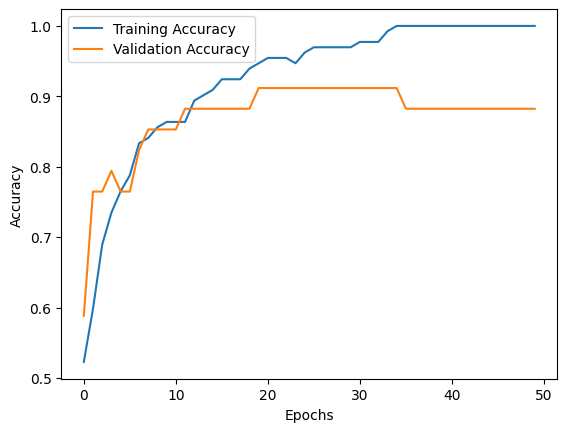

In [20]:
# Plotting Training performance

plt.plot(model.history.history['accuracy'], label='Training Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

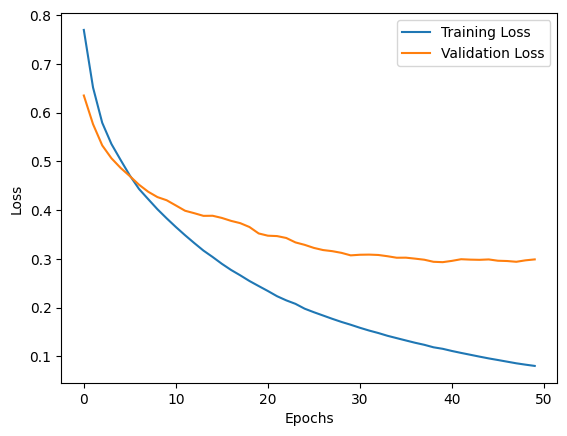

In [21]:
# Plotting model loss

plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()